#**Machine Translation**








Let's download our dataset of English and Spanish translations.

In [1]:
import pathlib
import keras
import os
import random

zip_path = keras.utils.get_file(
    origin="http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip",
    fname='spa-eng.zip',
    extract=True # Download
)

# Construct text_path with the correct subdirectory
text_path = os.path.join(zip_path+'/spa-eng/', 'spa.txt')

# Let's iterate over all lines in the text file (pairs of English and Spanish translations) and split by line breaks
with open(text_path) as f:

    # The [:-1] is dropping the final empty line of the text file.
    lines = f.read().split("\n")[:-1]

# Let's put our English-Spanish text pairs into a list; the sentences are split by a tab character.
text_pairs = []
for line in lines:

    # With each line from the text file, a tab character separates English (X) from Spanish (Y).
    english, spanish = line.split("\t")

    # We will add a [start] and [end] token to the Spanish sequence.
    # These tokens provide the model a way to start and end its translations.
    # [start] is the first word we will feed to our decoder to kick-off the translation output.
    # [end] is the token that signals to the model that, when it appears, we are done translating.
    spanish = "[start] " + spanish + " [end]"
    text_pairs.append((english, spanish))

# Let's pull a random example pair.
random.choice(text_pairs)

2638744/2638744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


("I'm almost done. Just give me a minute.",
 '[start] Casi he terminado. Dame un minuto. [end]')

Randomly shuffling the observations

In [8]:
# Shuffle the data to make a training and validation split.
random.shuffle(text_pairs)

# Define split percentages
train_split = 0.70  # 70% for training
val_split = 0.15   # 15% for validation
test_split = 0.15  # 15% for testing

# Calculate the number of samples for each split
total_samples = len(text_pairs)
train_samples = int(train_split * total_samples)
val_samples = int(val_split * total_samples)
test_samples = int(test_split * total_samples)

# Create the splits
train_pairs = text_pairs[:train_samples]
val_pairs = text_pairs[train_samples:train_samples + val_samples]
test_pairs = text_pairs[train_samples + val_samples:]

We need TextVectorization layers to convert raw text into integer indices. Let's create one for each language.

In [9]:
import string
import re
import tensorflow as tf
from keras import layers

# Remove preceding question mark symbols in Spanish text; we need to add this to the punctuation list for removal.
# For proper translation, you'd have to 'pre-pend' the question mark at the end of the translation process if you spit out a question mark at the end of a sentence.
strip_chars = string.punctuation + "¿"

# By default, our string.punctuation includes square brackets. We don't want to throw those out, though.
# So, we are going to drop [ and ] from the standard punctuation list.
strip_chars = strip_chars.replace("[", "")
strip_chars = strip_chars.replace("]", "")

# Lower case everything, and replace punctuation with nothing, except for [ and ].
# Note, in practice, we would keep punctuation and treat each as a separate token for prediction.
def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(
        lowercase, f"[{re.escape(strip_chars)}]", "")

# We will make indices for the 15,000 most common words in each language.
vocab_size = 15000

# We will work with sequences of exactly 20 words
sequence_length = 20

english_tokenizer = layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length,
)

# Note that we have 21 values in Spanish sequences, because we have to predict the 'end' token.
spanish_tokenizer = layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length + 1,
    standardize=custom_standardization,
)

train_english_texts = [pair[0] for pair in train_pairs]
train_spanish_texts = [pair[1] for pair in train_pairs]

english_tokenizer.adapt(train_english_texts)
spanish_tokenizer.adapt(train_spanish_texts)

Now we will tokenize all of our text pairs into NumPy arrays and create the decoder inputs and targets.

In [10]:
import numpy as np

# Tokenize all English and Spanish texts for train, val, and test sets.
train_eng_texts = [pair[0] for pair in train_pairs]
train_spa_texts = [pair[1] for pair in train_pairs]
val_eng_texts = [pair[0] for pair in val_pairs]
val_spa_texts = [pair[1] for pair in val_pairs]

# Convert each list of raw text into integer sequences using our tokenizers.
train_eng = english_tokenizer(train_eng_texts).numpy()
train_spa = spanish_tokenizer(train_spa_texts).numpy()
val_eng = english_tokenizer(val_eng_texts).numpy()
val_spa = spanish_tokenizer(val_spa_texts).numpy()

# Now we create the decoder inputs and targets from the Spanish sequences.

# Decoder input: everything except the last token (drop [end])
train_decoder_input = train_spa[:, :-1]
# Target: everything except the first token (drop [start])
train_targets = train_spa[:, 1:]

val_decoder_input = val_spa[:, :-1]
val_targets = val_spa[:, 1:]

# We create sample weights so that padded positions (value 0) don't count toward the loss.
train_sample_weights = (train_targets != 0).astype(np.float32)
val_sample_weights = (val_targets != 0).astype(np.float32)

### Understanding the Input/Target Offset

The `format_dataset()` function creates a crucial alignment between decoder input and training target. Here is what happens to a Spanish sequence:

```
Original sequence:    [start]  Hola   mundo  [end]

Decoder input:        [start]  Hola   mundo          ← remove [end]
Training target:               Hola   mundo  [end]   ← remove [start]
```

At each position, the model sees everything up to (and including) that position in the decoder input, and must predict the corresponding target:

- Position 0: sees `[start]` → predicts `Hola`
- Position 1: sees `[start] Hola` → predicts `mundo`  
- Position 2: sees `[start] Hola mundo` → predicts `[end]`

All positions are predicted **simultaneously** in one forward pass (teacher forcing). The model’s output shape is `(batch_size, sequence_length, vocab_size)` — a probability distribution at every position. The loss is the average cross-entropy across all positions.

At **inference**, we don’t have the Spanish sequence in advance. So we start with just `[start]`, predict the first word, feed it back, predict the next, and repeat until we get `[end]`.

Here is what the batches from our dataset now look like...

In [11]:
# We use both the English and Spanish sequences as input during training.
# train_eng is the encoder input.
print(train_eng[0])

# train_decoder_input is the sequence of spanish words, beginning with [start]
print(train_decoder_input[0])

# train_targets is the sequence of spanish words, shifted to the right (no start)
print(train_targets[0])

# We can see that the sample weights (mask) mean padding is ignored in loss.
print(train_sample_weights[0])

[  17  501    8 1449    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
[   2   40  913   12 1596    3    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
[  40  913   12 1596    3    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
[1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Let's create our Neural Network for Training

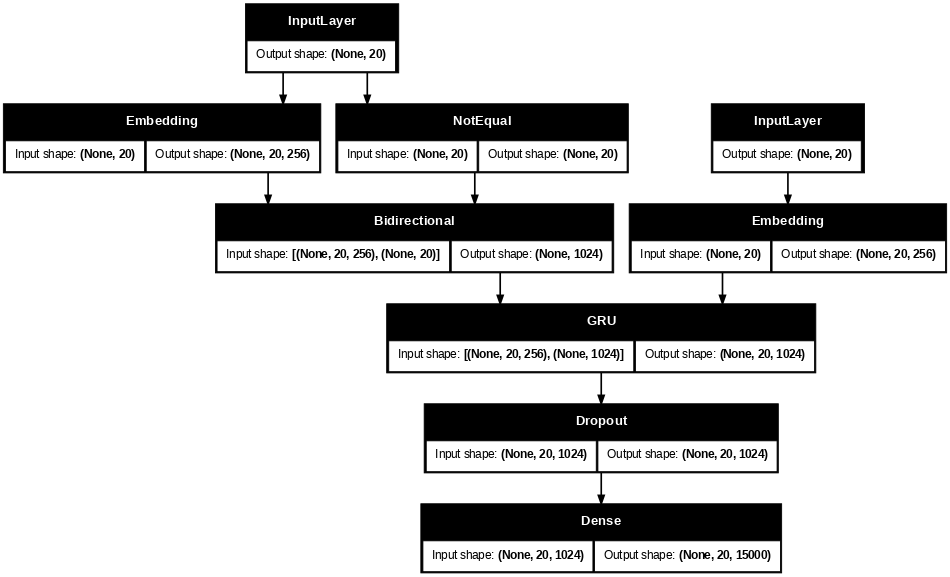

In [13]:
embed_dim = 256
hidden_dim = 1024

# Here is the encoder portion.
# It will accept an English sequence as input, convert the tokens to embeddings
# and pass those sequences of word embeddings into a pair of RNNs (bidirectional) to encode the sequence into a 1,024 dimensional embedded representation.
source = keras.Input(shape=(20,), dtype="int32", name="english")
x = layers.Embedding(vocab_size, embed_dim, mask_zero=True)(source)
encoder_output = layers.Bidirectional(layers.GRU(hidden_dim), merge_mode="sum")(x)

# Here is the decoder portion of the network.
# It accepts the Spanish sequence (vectorized) as input, which again goes into its own embedding layer, yielding embedded Spanish sequences.
# Those sequences of embedded Spanish words go into their own RNN (unidirectional this time).
# Importantly, *that* RNN implicitly takes the output from the encoder portion as input; the 1,024 embedding of the English sentence is used as the first hidden state for this RNN.
target = keras.Input(shape=(20,), dtype="int32", name="spanish")
x = layers.Embedding(vocab_size, embed_dim, mask_zero=True)(target)

# Notice that we produce output at each step of the sequence.
x = layers.GRU(hidden_dim, return_sequences=True)(x, initial_state=encoder_output)
x = layers.Dropout(0.5)(x)

# NOTE: The GRU outputs (batch, seq_len, hidden_dim) because return_sequences=True.
# The Dense layer applies the SAME weights at every position, producing
# (batch, seq_len, vocab_size) — one softmax prediction per position.

# So, we produce 20 * vocab size softmax predictions for each sequence, in parallel. Our model is learning to predict the next word in the Spanish sequence given the words processed thus far
# And the entire English sequence.
target_predictions = layers.Dense(vocab_size, activation="softmax")(x)

# Wrap these things together into a single big Keras model now.
# We connect the aligned English and Spanish sequences as input, to the step ahead Spanish output.
seq2seq_rnn = keras.Model([source, target], target_predictions)

# Notice the shape of the Dense output layer... 15,000 is the softmax dimension (vocabulary size)
# We will produce 20 different 15,000 dimensional softmax predictions.
# I've specified the Input layer dimension as (20,) here to make clear how shapes propagate to the output layer.
# We could have left this as None, to allow for variable sequence lengths if we wanted.
keras.utils.plot_model(seq2seq_rnn, show_shapes=True, dpi=60)

Okay, let's train the model...

In [14]:
seq2seq_rnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    weighted_metrics=["accuracy"],
)

seq2seq_rnn.fit(
    {"english": train_eng, "spanish": train_decoder_input},
    train_targets,
    sample_weight=train_sample_weights,
    batch_size=64,
    epochs=15,
    validation_data=(
        {"english": val_eng, "spanish": val_decoder_input},
        val_targets,
        val_sample_weights,
    ),
)

Epoch 1/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 59s 41ms/step - accuracy: 0.3550 - loss: 3.6729 - val_accuracy: 0.4944 - val_loss: 2.5072
Epoch 2/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 53s 41ms/step - accuracy: 0.5325 - loss: 2.2690 - val_accuracy: 0.5907 - val_loss: 1.8986
Epoch 3/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 52s 40ms/step - accuracy: 0.6198 - loss: 1.6400 - val_accuracy: 0.6319 - val_loss: 1.6590
Epoch 4/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 53s 41ms/step - accuracy: 0.6790 - loss: 1.2500 - val_accuracy: 0.6473 - val_loss: 1.5878
Epoch 5/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 52s 40ms/step - accuracy: 0.7268 - loss: 0.9906 - val_accuracy: 0.6538 - val_loss: 1.5849
Epoch 6/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 52s 40ms/step - accuracy: 0.7628 - loss: 0.8209 - val_accuracy: 0.6601 - val_loss: 1.5999
Epoch 7/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 52s 40ms/step - accuracy: 0.7876 - loss: 0.7137 - val_accuracy: 0.6608 - val_loss: 1.6338
Epoch 8/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 53s 40ms/step - accuracy: 0.8056 -

Now we can use the resulting network to generate translations, feeding output word predictions back into the network at each step until our translation is done.

In [17]:
import numpy as np

# We need our spanish vocabulary and dictionary to convert integers to words.
spa_vocab = spanish_tokenizer.get_vocabulary()
spa_index_lookup = dict(zip(range(len(spa_vocab)), spa_vocab))

# We write a 'translation' function that wraps our model.
# The function accepts an english sentence as input. In then tokenizes it, and instantiates the output sentence with just a [start] token.
# We will then spit out 20 tokens of text (potentially empty tokens if the sentence finishes).

def generate_translation(input_sentence):
    tokenized_input_sentence = english_tokenizer([input_sentence])
    decoded_sentence = "[start]"
    for i in range(sequence_length):

        # At each pass, we obtain the tokenized representation of the output sentence at the current point in time. Initially it is just [start] but it will include more words as we loop.
        # Note, we strip the last token because our tokenizer produces sequences of seq length + 1 = 21.
        tokenized_target_sentence = spanish_tokenizer([decoded_sentence])[:, :-1]

        # At a given step, the model takes the English input sentence along with the Spanish output that has been generated thus far.
        inputs = [tokenized_input_sentence, tokenized_target_sentence]

        # We predict the next token in the sequence.
        next_token_predictions = seq2seq_rnn.predict(inputs, verbose=0)

        # We take an arg-max of the prediction at the appropriate index in the output (output token i)
        # NOTE: this is a very inefficient approach, because our model is generating token predictions at positions in the output sequence that are already done being predicted in prior iterations!
        sampled_token_index = np.argmax(next_token_predictions[0, i, :])

        # We convert that predicted integer token into a word
        sampled_token = spa_index_lookup[sampled_token_index]

        # We add our predicted word to the output sequence and then repeat
        decoded_sentence += " " + sampled_token

        # If we predicted '[end]' then we stop the process.
        if sampled_token == "[end]":
            break

    return decoded_sentence

Now, let's see how our trained model does. It works!

In [18]:
test_eng_texts = ["Hey how are you doing?","What's your favorite color?"]

for text in test_eng_texts:
    input_sentence = text
    print("-")
    print(input_sentence)
    print(generate_translation(input_sentence))

-
Hey how are you doing?
[start] ¡eh qué estás haciendo [end]
-
What's your favorite color?
[start] cuál es tu color preferido [end]


#*Let's Now Replace our RNN's with Transformers*

Transformers are an architecture that wraps Multi-head Attention Layers (QKV Attention).

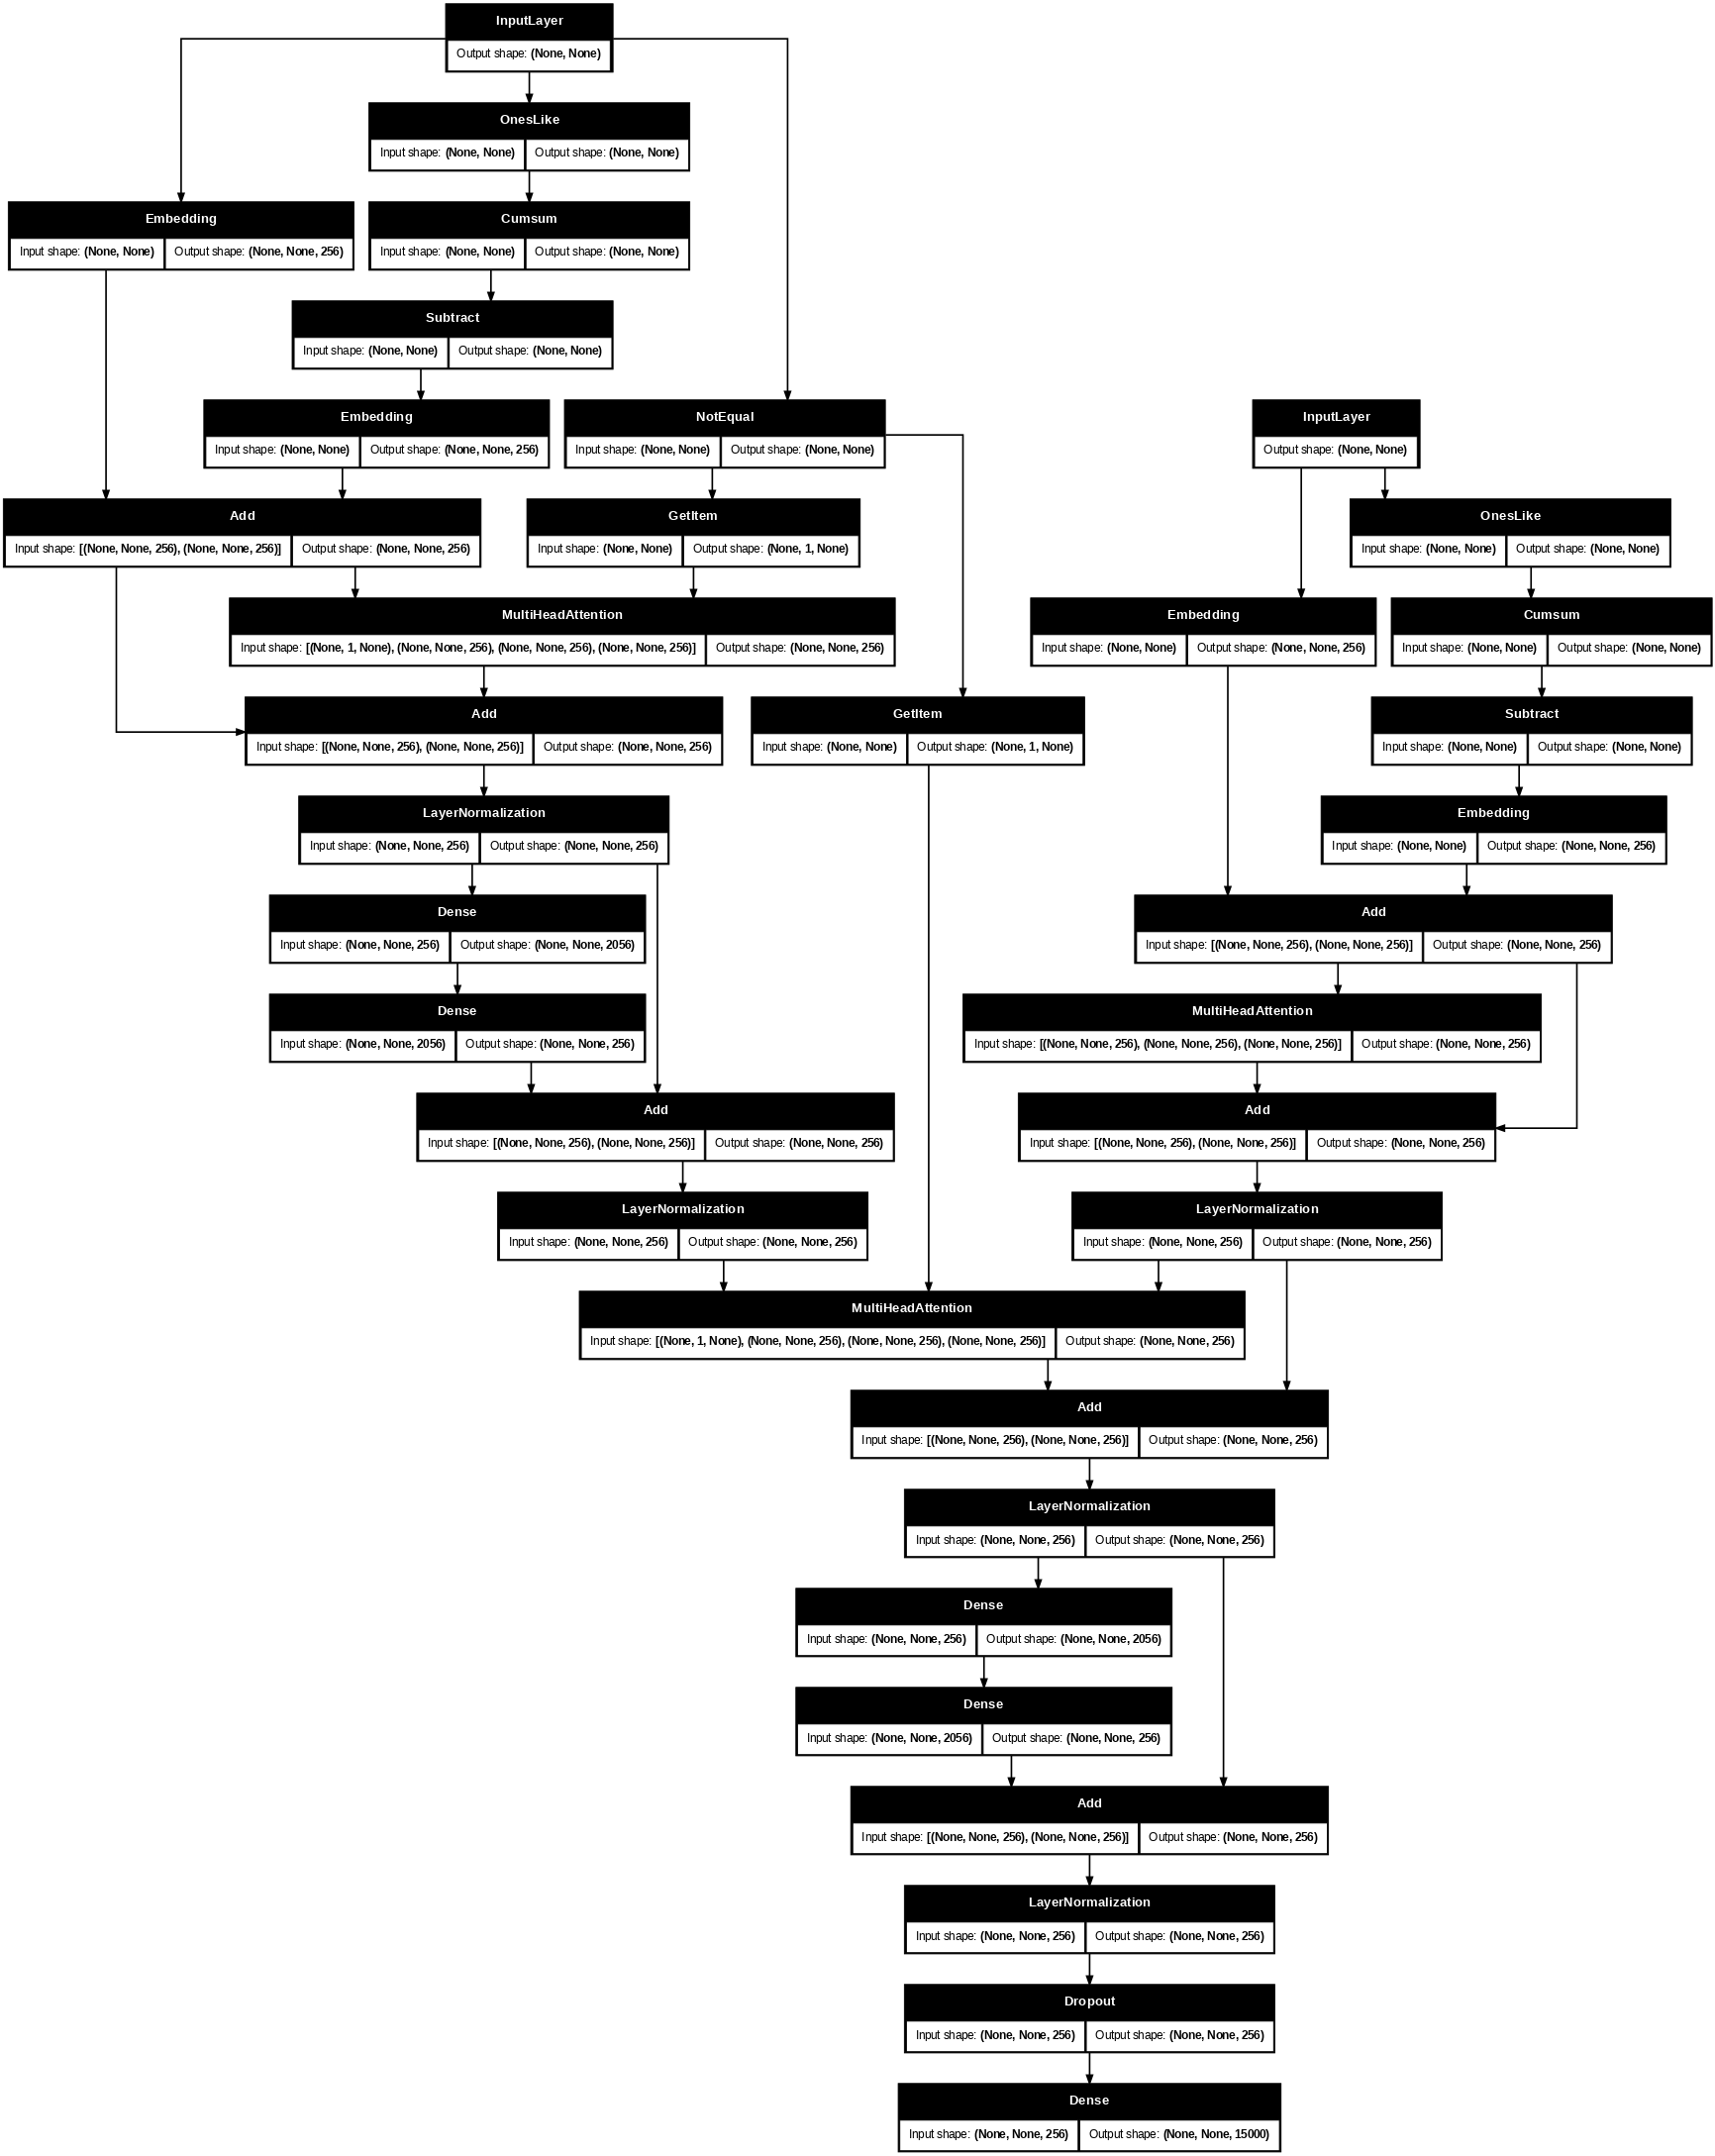

In [21]:
from keras import ops

hidden_dim = 256
intermediate_dim = 2056
num_heads = 8

# --- ENCODER ---
source = keras.Input(shape=(None,), dtype="int32", name="english")

# Positional embedding for English input
token_embed_enc = layers.Embedding(vocab_size, hidden_dim)(source)

# Here, we make a vector of 1, 2, 3, ... indexing each position in the sequence.
# We then get embeddings per position index.
positions_enc = ops.cumsum(ops.ones_like(source), axis=-1) - 1
position_embed_enc = layers.Embedding(sequence_length, hidden_dim)(positions_enc)

# We then add the position and token embeddings (we shift a word's embedding depending on where it appears)
enc = token_embed_enc + position_embed_enc

# Padding mask for encoder self-attention (ignore padded 0s)
source_mask = source != 0  # (batch, seq_len) — True where real tokens exist

# Encoder self-attention + residual + layernorm
enc_residual = enc
enc = layers.MultiHeadAttention(
    num_heads=num_heads, key_dim=hidden_dim // num_heads
)(query=enc, key=enc, value=enc, attention_mask=source_mask[:, None, :])

# We have a residual connection around the attention layer
# And we do within-embedding normalization.
enc = enc + enc_residual
enc = layers.LayerNormalization()(enc)

# Encoder feed-forward + residual + layernorm
# Note that this is an inverted bottelneck (expand out and back in)
enc_residual = enc
enc = layers.Dense(intermediate_dim, activation="relu")(enc)
enc = layers.Dense(hidden_dim)(enc)
enc = enc + enc_residual
encoder_output = layers.LayerNormalization()(enc)

# --- DECODER ---
target = keras.Input(shape=(None,), dtype="int32", name="spanish")

# Positional embedding for Spanish input
token_embed_dec = layers.Embedding(vocab_size, hidden_dim)(target)
positions_dec = ops.cumsum(ops.ones_like(target), axis=-1) - 1
position_embed_dec = layers.Embedding(sequence_length, hidden_dim)(positions_dec)
dec = token_embed_dec + position_embed_dec

# Decoder causal self-attention + residual + layernorm
dec_residual = dec

# Here, we apply a causal mask, which means 'only look at words to the left'
# We do this to force the model not to look at / attend to words it wont have
# in the Decoder input at inference time.
dec = layers.MultiHeadAttention(
    num_heads=num_heads, key_dim=hidden_dim // num_heads
)(query=dec, key=dec, value=dec, use_causal_mask=True)
dec = dec + dec_residual
dec = layers.LayerNormalization()(dec)

# Decoder cross-attention (attends to encoder output) + residual + layernorm
dec_residual = dec

# Note: spanish so far is the query, english is the key, english is the value.
dec = layers.MultiHeadAttention(
    num_heads=num_heads, key_dim=hidden_dim // num_heads
)(query=dec, key=encoder_output, value=encoder_output, attention_mask=source_mask[:, None, :])
dec = dec + dec_residual
dec = layers.LayerNormalization()(dec)

# Decoder feed-forward + residual + layernorm
dec_residual = dec

# Inveted bottleneck again - expand out and back in.
dec = layers.Dense(intermediate_dim, activation="relu")(dec)
dec = layers.Dense(hidden_dim)(dec)
dec = dec + dec_residual
dec = layers.LayerNormalization()(dec)

# Output - this is deceptive! It looks like 1 token is being predicted.
# However, the shape of the input to the Dense layer is a batch of vector sequences.
# NOT a batch of vectors. The additional dimension to the input means the
# Dense layer will produce 20 predictions at once (one for each position of the decoder input.)
# All those predictions will share the same weight matrix though (hence the efficiency gain in training).
dec = layers.Dropout(0.5)(dec)
target_predictions = layers.Dense(vocab_size, activation="softmax")(dec)

transformer = keras.Model([source, target], target_predictions)
keras.utils.plot_model(transformer, show_shapes=True, dpi=60)

Now let's compile and train the model.

In [22]:
transformer.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    weighted_metrics=["accuracy"],
)

transformer.fit(
    {"english": train_eng, "spanish": train_decoder_input},
    train_targets,
    sample_weight=train_sample_weights,
    batch_size=64,
    epochs=15,
    validation_data=(
        {"english": val_eng, "spanish": val_decoder_input},
        val_targets,
        val_sample_weights,
    ),
)

Epoch 1/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 83s 40ms/step - accuracy: 0.3879 - loss: 1.4256 - val_accuracy: 0.5389 - val_loss: 0.9424
Epoch 2/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5844 - loss: 0.8723 - val_accuracy: 0.6327 - val_loss: 0.7126
Epoch 3/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6571 - loss: 0.6650 - val_accuracy: 0.6624 - val_loss: 0.6301
Epoch 4/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6983 - loss: 0.5461 - val_accuracy: 0.6799 - val_loss: 0.5915
Epoch 5/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7266 - loss: 0.4688 - val_accuracy: 0.6864 - val_loss: 0.5791
Epoch 6/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7496 - loss: 0.4129 - val_accuracy: 0.6959 - val_loss: 0.5636
Epoch 7/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7682 - loss: 0.3697 - val_accuracy: 0.6989 - val_loss: 0.5690
Epoch 8/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7841 - loss: 

And we can use the new model in the same way to generate translations...

In [23]:
import numpy as np

spa_vocab = spanish_tokenizer.get_vocabulary()
spa_index_lookup = dict(zip(range(len(spa_vocab)), spa_vocab))

def generate_translation(input_sentence):
    tokenized_input_sentence = english_tokenizer([input_sentence])
    decoded_sentence = "[start]"
    for i in range(sequence_length):
        # Note, we strip the last token because our tokenizer produces sequences of seq length + 1 = 21.
        tokenized_target_sentence = spanish_tokenizer([decoded_sentence])[:, :-1]
        inputs = [tokenized_input_sentence, tokenized_target_sentence]
        next_token_predictions = transformer.predict(inputs, verbose=0)
        sampled_token_index = np.argmax(next_token_predictions[0, i, :])
        sampled_token = spa_index_lookup[sampled_token_index]
        decoded_sentence += " " + sampled_token
        if sampled_token == "[end]":
            break
    return decoded_sentence

test_eng_texts = [pair[0] for pair in test_pairs]
for _ in range(5):
    input_sentence = random.choice(test_eng_texts)
    print("-")
    print(input_sentence)
    print(generate_translation(input_sentence))

-
You remember Tom, don't you?
[start] te acuerdas de tom no [end]
-
I know what you all are thinking.
[start] sé lo que estáis pensando [end]
-
He said that you need not go.
[start] Él dijo que no debes ir [end]
-
The days are getting longer and longer.
[start] los días se están más y más largos [end]
-
This beer is not cold enough.
[start] esta cerveza no está más fría [end]
